<a href="https://colab.research.google.com/github/saachi-surana/Path2Profit/blob/main/Path2Profit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('online_shoppers_intention.csv')

In [ ]:
dataset.shape

(12330, 18)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
dataset.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [ ]:
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


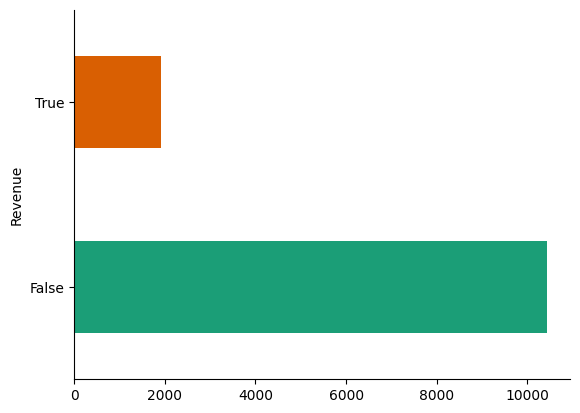

In [ ]:
dataset.groupby('Revenue').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
dataset.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [ ]:
dataset['OperatingSystems'] = dataset['OperatingSystems'].astype('str')
dataset['Browser'] = dataset['Browser'].astype('str')
dataset['Region'] = dataset['Region'].astype('str')
dataset['TrafficType'] = dataset['TrafficType'].astype('str')
dataset['Weekend'] = dataset['Weekend'].astype('str')
dataset['Revenue'] = dataset['Revenue'].astype('str')

In [ ]:
dataset.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems            object
Browser                     object
Region                      object
TrafficType                 object
VisitorType                 object
Weekend                     object
Revenue                     object
dtype: object

In [ ]:
dataset['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

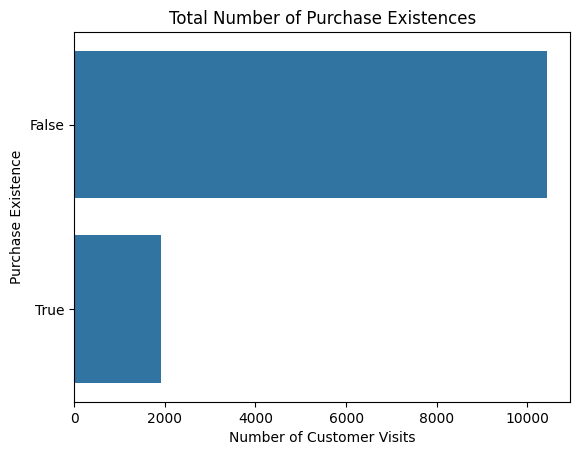

In [ ]:
sns.countplot(data = dataset['Revenue'])
plt.xlabel('Number of Customer Visits')
plt.ylabel('Purchase Existence')
plt.title('Total Number of Purchase Existences')
plt.show()

In [ ]:
obj_set = [f for f in dataset.columns if dataset.dtypes[f] == 'object']
obj_set = dataset[obj_set]

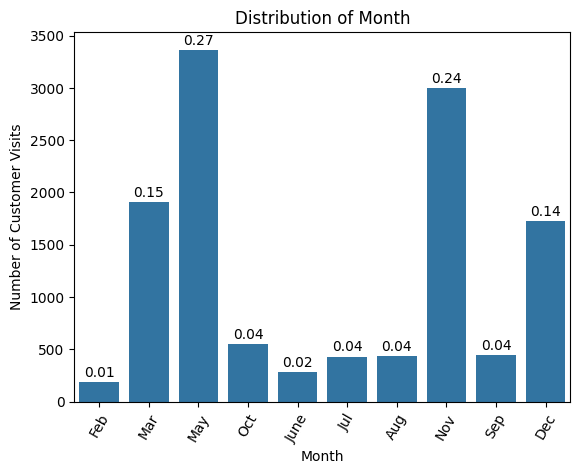

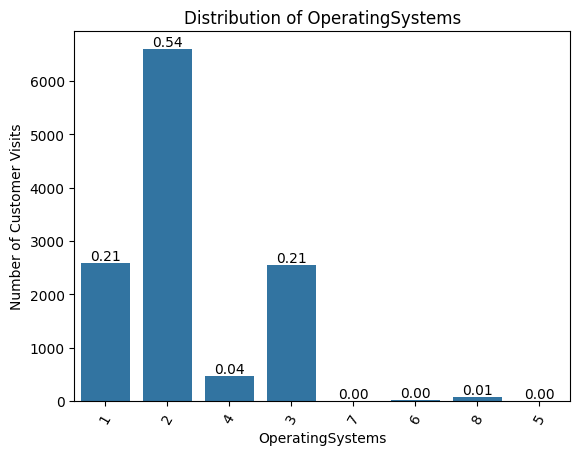

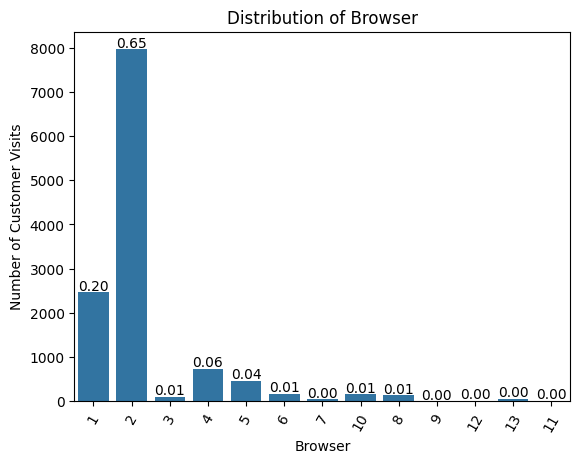

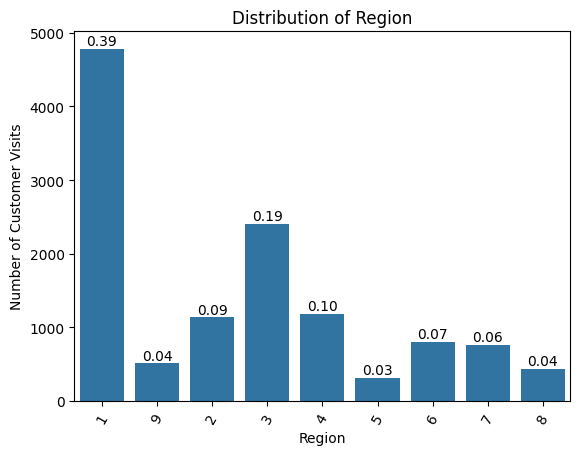

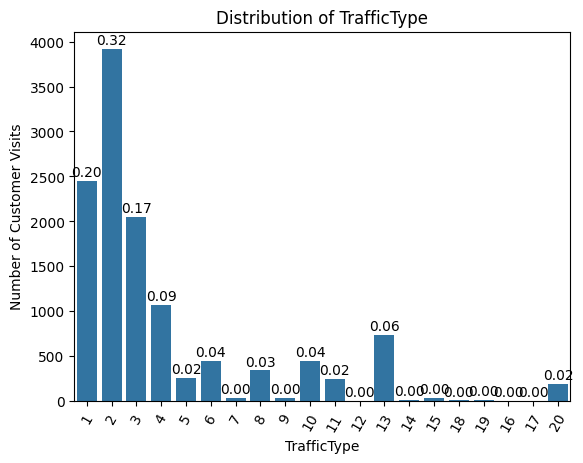

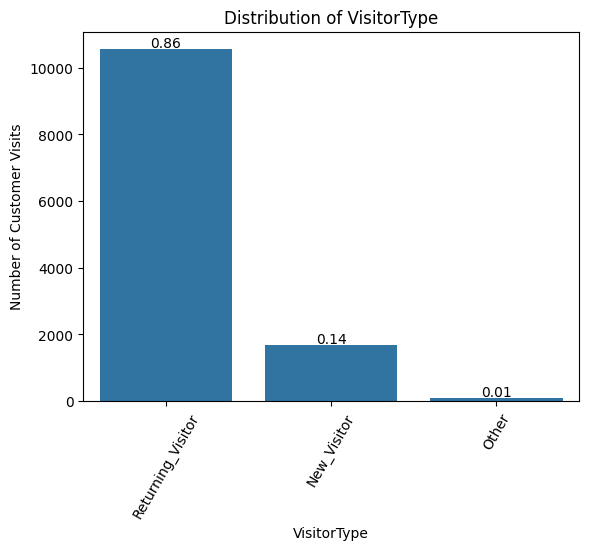

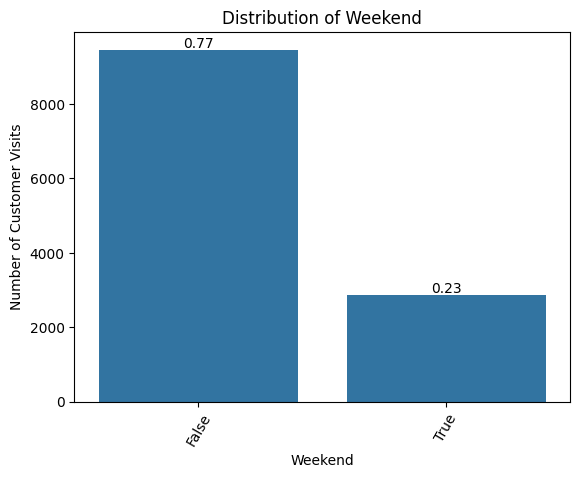

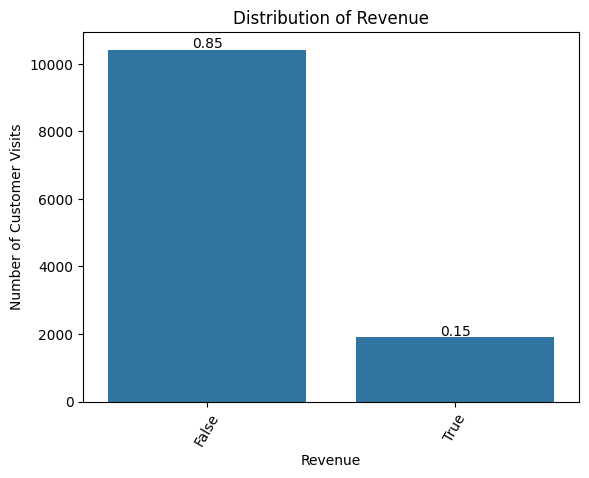

In [ ]:
for var in obj_set.columns:
    ax = sns.countplot(x = dataset[var], data = dataset)
    total = float(len(dataset[var]))
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 50,
                '{:1.2f}'.format(height/total),
                ha="center")
    plt.title('Distribution of ' + str(var))
    plt.ylabel('Number of Customer Visits')
    plt.xticks(rotation = 60)
    plt.show()

In [ ]:
for var in obj_set.columns:
    print(dataset[var].value_counts())

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64
Weekend
False    9462
True     2868
Na

In [ ]:
num_set = [f for f in dataset.columns if dataset.dtypes[f] != 'object']
num_set = dataset[num_set]

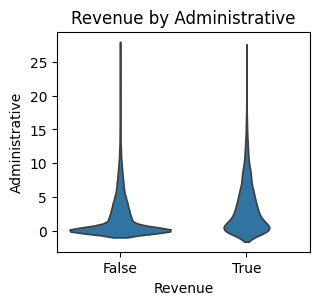

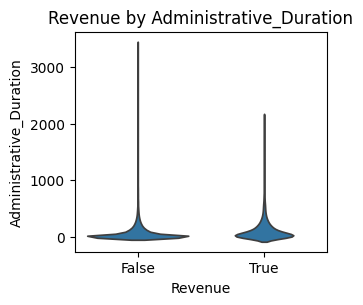

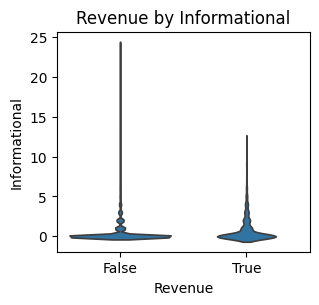

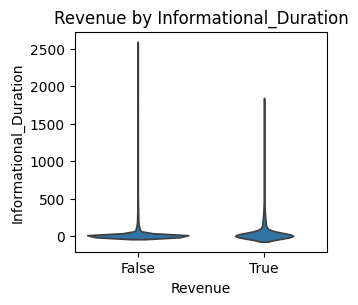

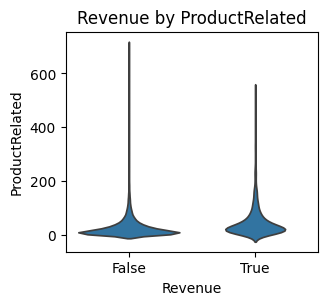

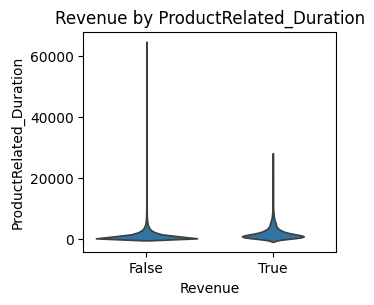

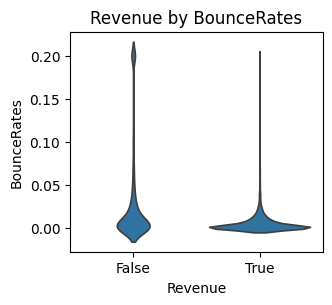

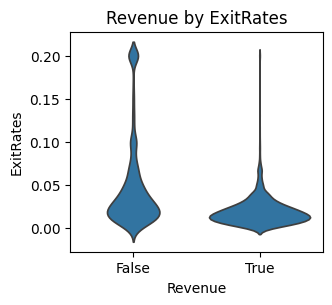

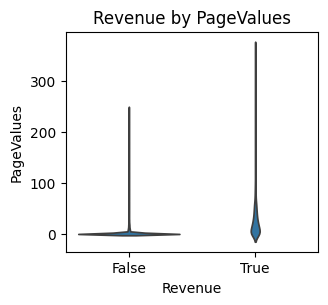

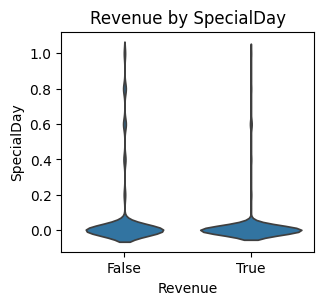

In [ ]:
num_all_columns = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

for i in range(len(num_all_columns)):
    plt.figure(figsize=(15, 20))
    plt.subplot(6, 4, i + 1)
    sns.violinplot(x=dataset['Revenue'], y=dataset[num_all_columns[i]], data=dataset, inner=None)
    plt.title('Revenue by {}'.format(num_all_columns[i]))
    plt.show()

<ipython-input-18-031bbe03cfb4>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_set[num_all_columns[i]])
<ipython-input-18-031bbe03cfb4>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(num_set[num_all_columns[i]])
<ipython-input-18-031bbe03cfb4>:9: UserWarning: 

`distplot` is a deprecated

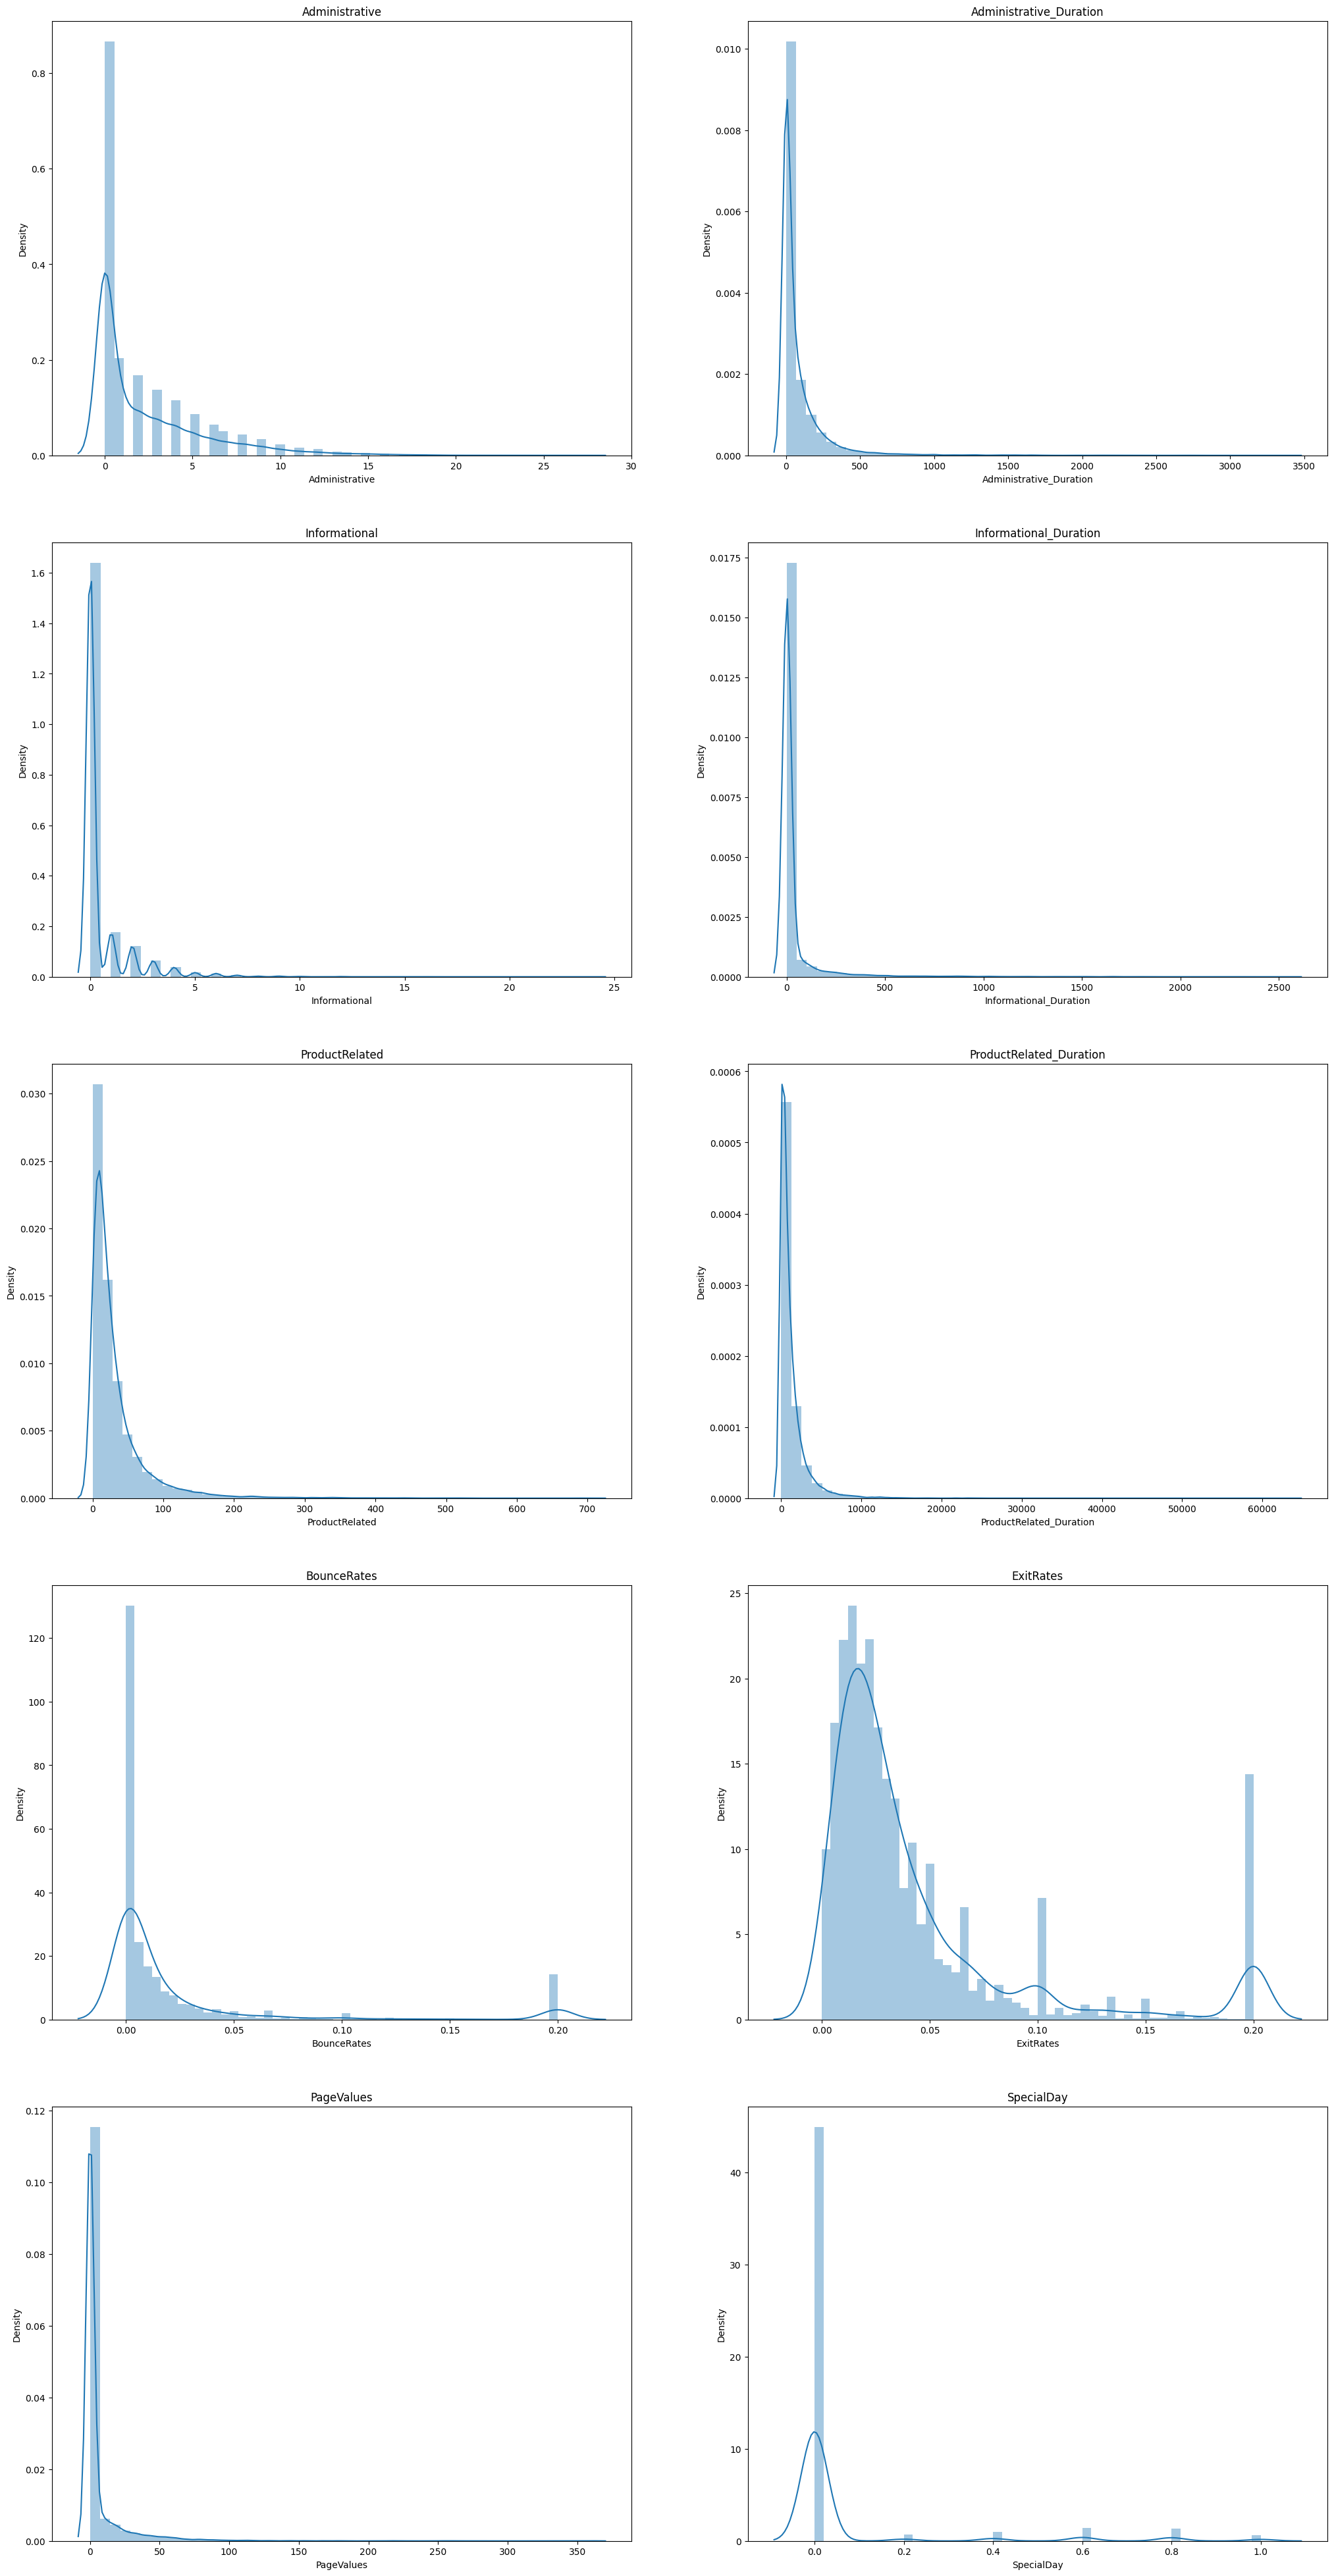

In [ ]:
num_all_columns = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

plt.figure(figsize=(25, 60))

for i in range(len(num_all_columns)):
    plt.subplot(6, 2, i + 1)
    sns.distplot(num_set[num_all_columns[i]])
    plt.title(num_all_columns[i])

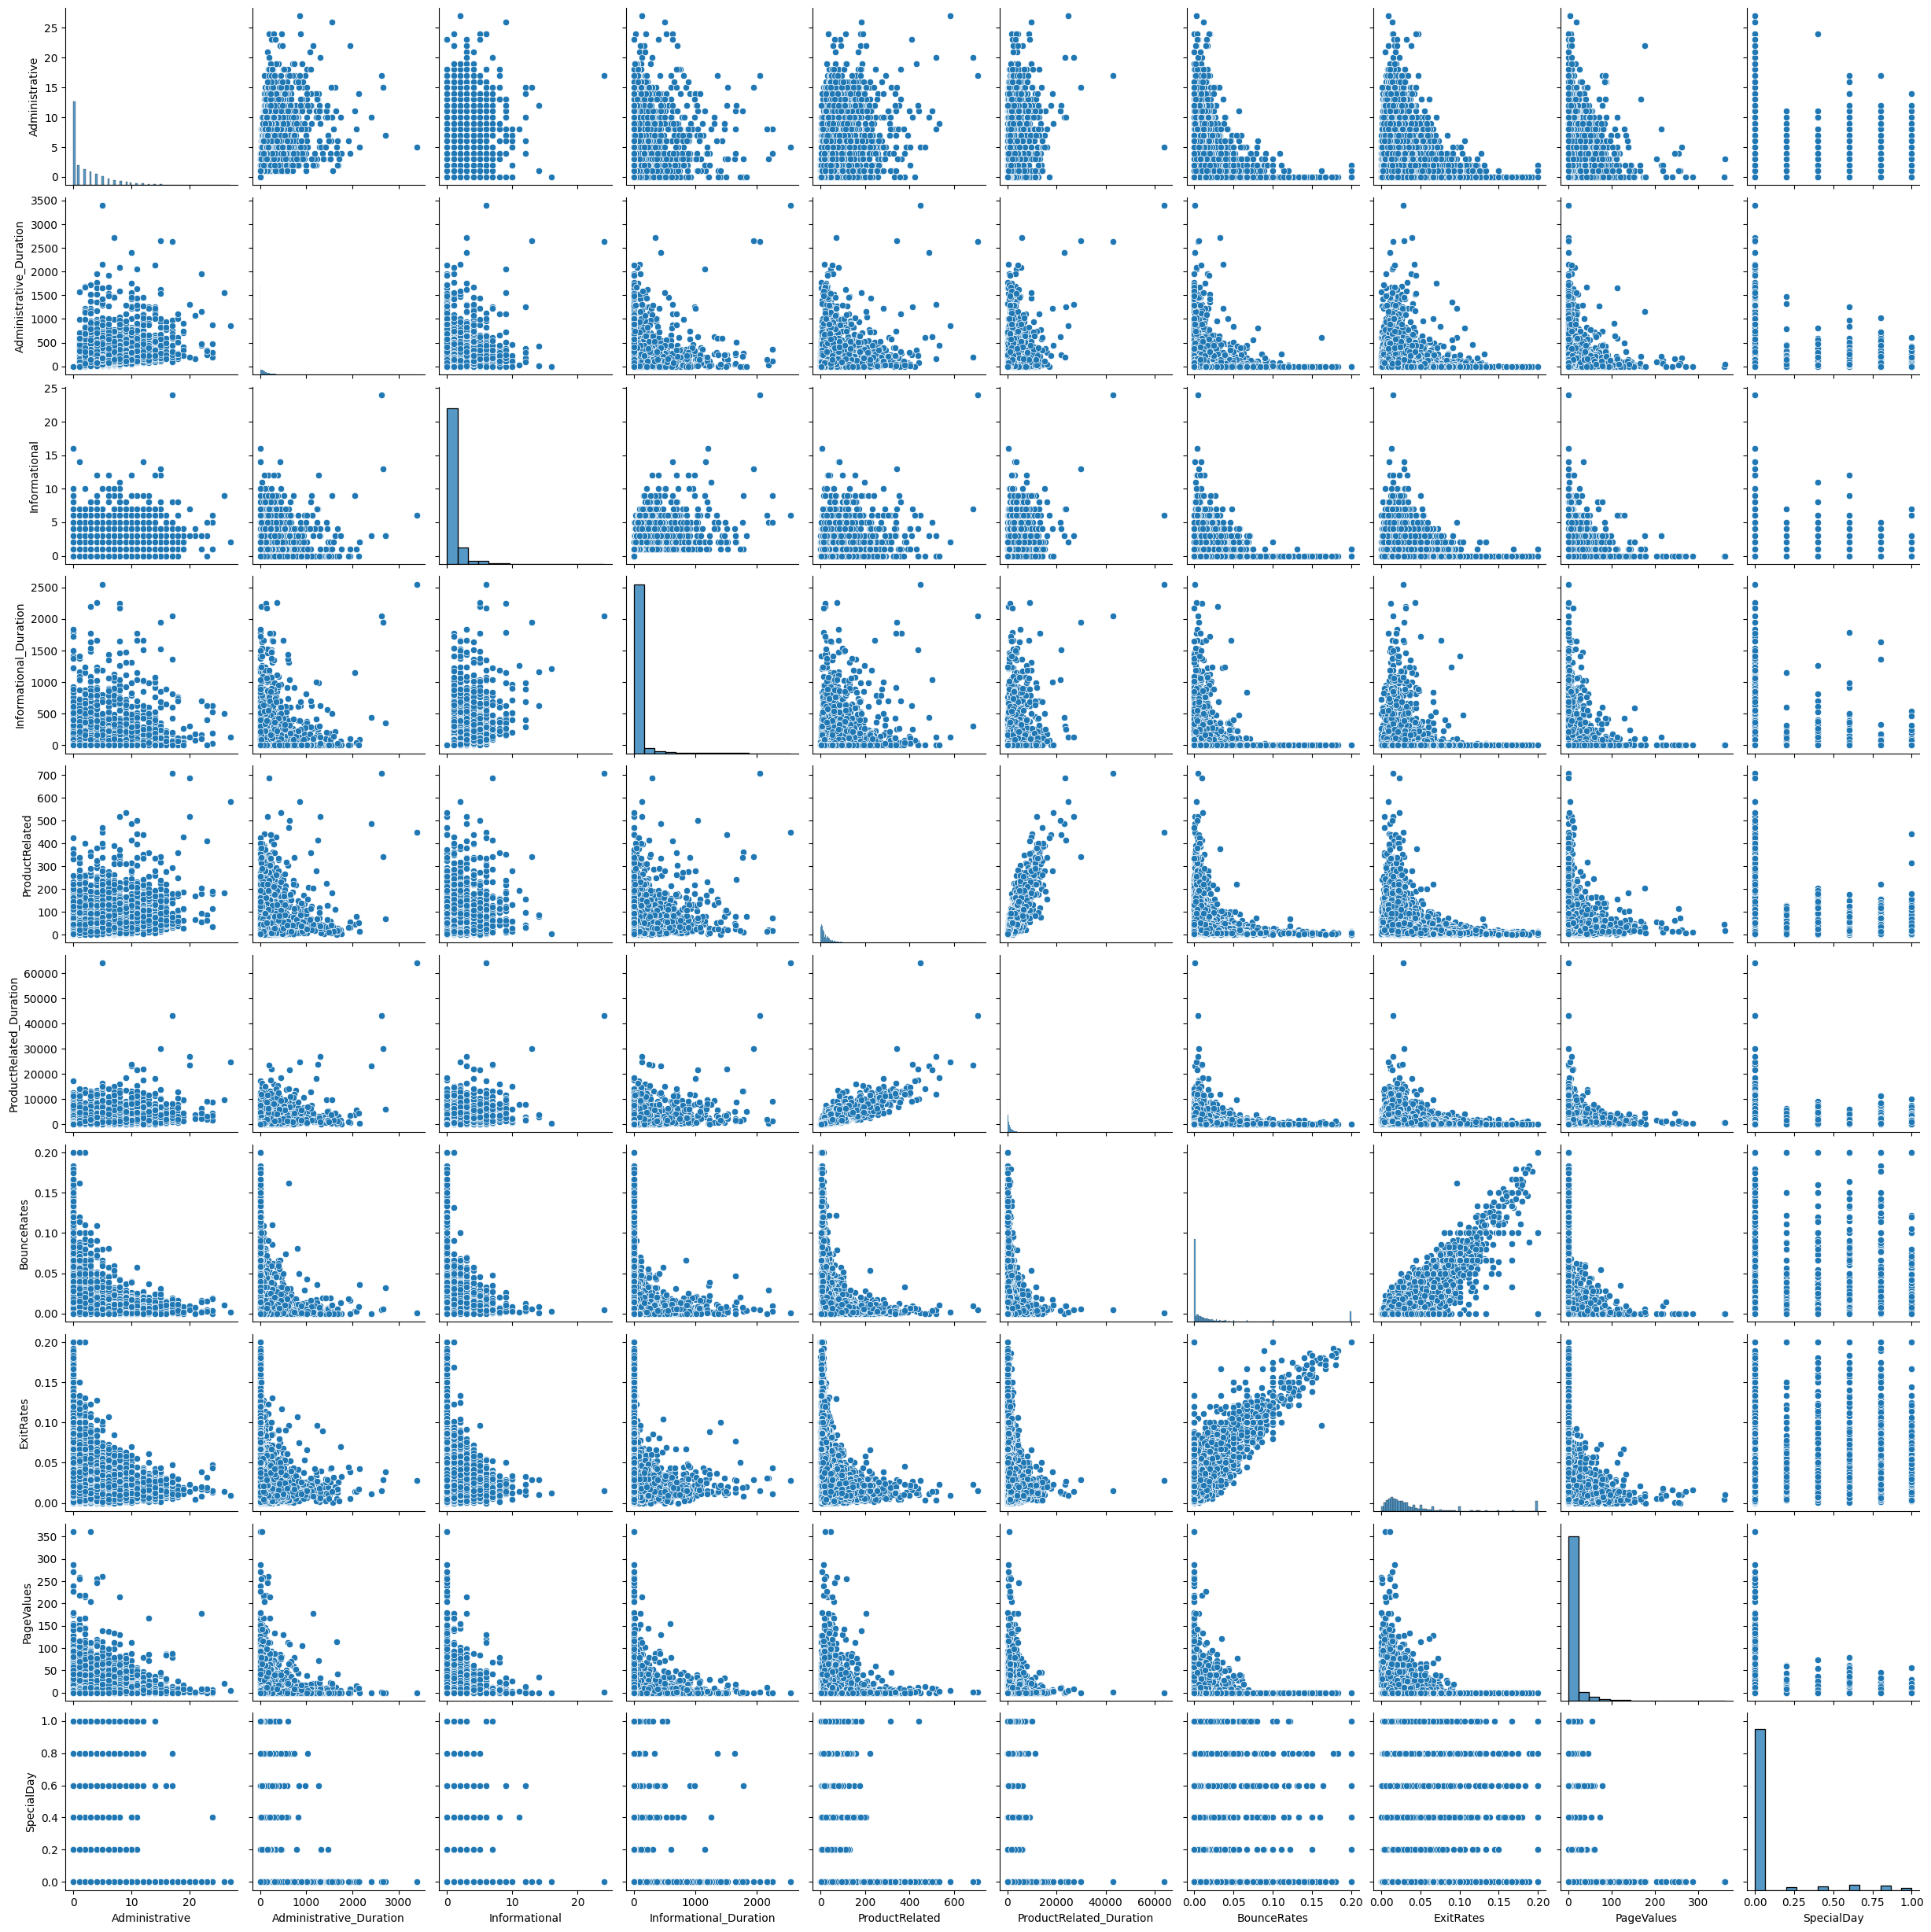

In [ ]:
sns.pairplot(num_set)
plt.show()

(10, 10)


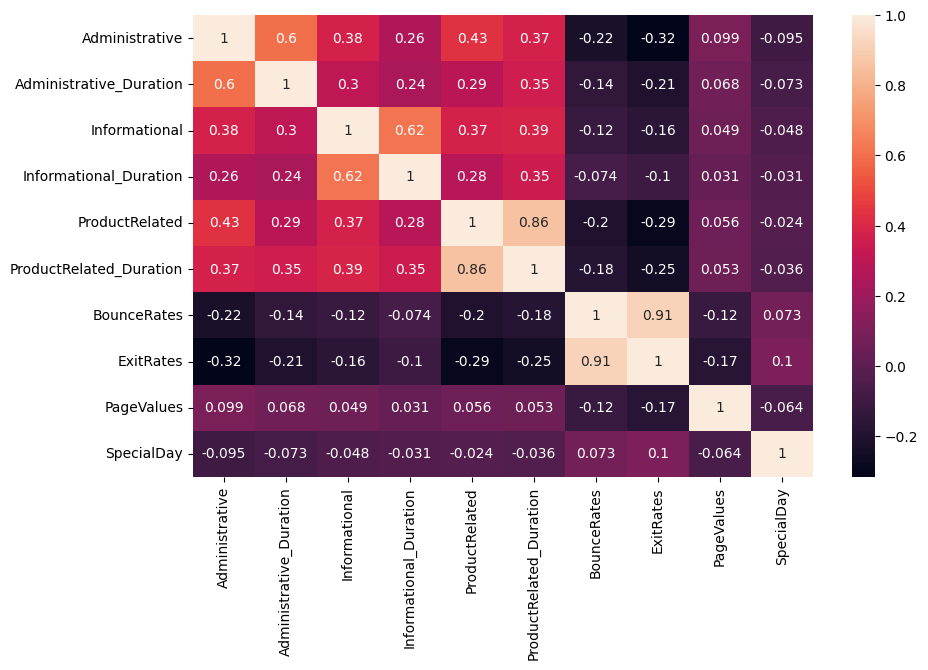

In [ ]:
corr_matrix = round(num_set.corr(), 3)
print(corr_matrix.shape)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [ ]:
new_num_set = num_set.drop(columns=['ProductRelated', 'ExitRates', 'Informational'])

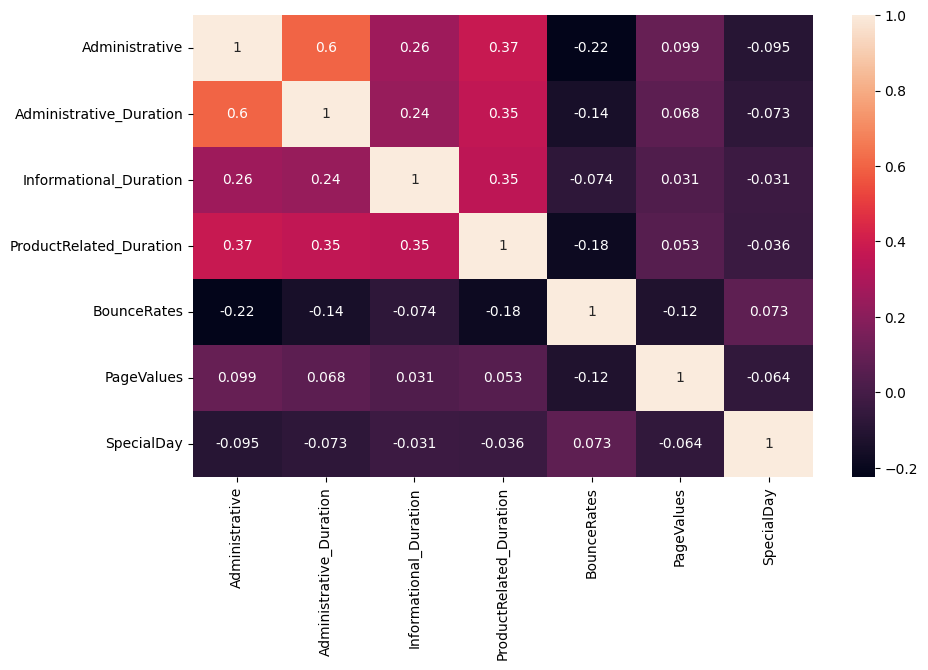

In [ ]:
new_corr_matrix = round(new_num_set.corr(), 3)

plt.figure(figsize=(10,6))
sns.heatmap(new_corr_matrix, annot=True)
plt.show()

In [ ]:
online_set = pd.concat([new_num_set, obj_set], axis = 1)

In [ ]:
  plt.figure(figsize=(20,20))
for i, col in enumerate(['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
       'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay'], start=1):
    plt.subplot(3, 3, i)
    num_set.boxplot(col,whis=1.5)

plt.show()

In [ ]:
y = online_set['Revenue']
x = online_set.drop(['Revenue'], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=2, stratify=y)

In [ ]:
x_train.head()

In [ ]:
y_train.head()

In [ ]:
y_train.replace({"False": 0, "True": 1}, inplace=True)
y_test.replace({"False": 0, "True": 1}, inplace=True)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
dum_obj_set = pd.get_dummies(obj_set)

In [ ]:
scaler = StandardScaler()
scaled_num_set = scaler.fit_transform(num_set)
num_set = pd.DataFrame(scaled_num_set, columns=num_set.columns)
x_train_transform = pd.concat([num_set.reset_index(drop=True), dum_obj_set.reset_index(drop=True)], axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encode_y_train = le.fit_transform(y_train)
y_train_transform = pd.DataFrame(encode_y_train)

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
num_ft = x_train.select_dtypes(include=['int64', 'float64']).columns
obj_ft = x_train.select_dtypes(include=['object']).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_ft),
        ('cat', categorical_transformer, obj_ft)])

In [ ]:
from pandas import set_option
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
classifiers = [
    LogisticRegression(),
    SVC(kernel='rbf', C=0.025, probability=True),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    XGBClassifier(),
    LGBMClassifier(),
    MLPClassifier()
    ]

In [ ]:
for classifier in classifiers:
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', classifier)
                            ])
    pipe.fit(x_train, y_train)
    print(classifier)
    print('Model score: %.3f' % pipe.score(x_test, y_test))

# Display classification report for all the models for model selection.
    y_pred = pipe.predict(x_test)
    results = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix: ')
    print(results)
    print('Classification Report: ')
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()
Model score: 0.878
Confusion Matrix: 
[[2032   52]
 [ 248  134]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.72      0.35      0.47       382

    accuracy                           0.88      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.86      0.88      0.86      2466

SVC(C=0.025, probability=True)
Model score: 0.874
Confusion Matrix: 
[[2051   33]
 [ 278  104]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2084
           1       0.76      0.27      0.40       382

    accuracy                           0.87      2466
   macro avg       0.82      0.63      0.67      2466
weighted avg       0.86      0.87      0.85      2466

DecisionTreeClassifier()
Model score: 0.863
Confusion Matrix: 
[[1921  163]
 [ 176  206]]
Classification Report: 
  

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
gb_class = GradientBoostingClassifier()
pipe_gb = Pipeline(steps=[('preprocessor', preprocessor),
                       ('gb_class', GradientBoostingClassifier())
                      ])
pipe_gb.fit(x_train, y_train)
print(gb_class)
print('Model score: %.3f' % pipe_gb.score(x_test, y_test))

# Display classification report for all the models for model selection.
y_pred_gb = pipe_gb.predict(x_test)
results_gb = confusion_matrix(y_test, y_pred_gb)
print('Confusion Matrix: ')
print(results_gb)
print('Classification Report: ')
print(classification_report(y_test, y_pred_gb))

GradientBoostingClassifier()
Model score: 0.902
Confusion Matrix: 
[[2003   81]
 [ 160  222]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2084
           1       0.73      0.58      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.80      2466
weighted avg       0.90      0.90      0.90      2466

